# 06 — PINN as a Differentiable Surrogate: Optimising a Control

Everything in notebooks 01–05 **solved** a physics problem. This notebook does something different and, for an
energy company, extremely valuable: it uses a trained PINN as a **differentiable digital twin** that we
**optimise against**.

The scenario continues notebook 05's **district-heating pipe**. The operator can change one knob — the **pump
speed**, i.e. the flow velocity $v$. Faster flow delivers hotter water to the customers (less time to cool on
the way), but **pumping power grows like $v^3$** (the pump "affinity law"), so speed is expensive. The business
question:

> *What pump speed delivers the required temperature at the lowest total energy cost?*

We answer it in two stages, and the key new idea is in stage 2:

1. **Train once, for all settings.** Train a *parametric* PINN $\theta(x; v)$ that knows the pipe's physics for
   **any** pump speed in a range — $v$ becomes an extra **input**.
2. **Optimise the knob by back-propagating through the frozen twin.** Because the PINN is differentiable, we can
   compute $\frac{dJ}{dv}$ of a cost function $J(v)$ *analytically through the network* and let gradient descent
   find the best $v$ — with **no PDE re-solve per candidate**. That is the "differentiable surrogate" superpower.

## 1. Why "differentiable surrogate" is a big deal

```
   CLASSICAL design/control loop            PINN SURROGATE loop
   ────────────────────────────            ───────────────────
   pick v  ─► run full PDE solver ─► cost   pick v ─► one cheap forward pass ─► cost
      ▲                                │        ▲                                │
      └──── finite-difference gradient ┘        └──── EXACT gradient dJ/dv ───────┘
            (re-solve for each v!)                    (autograd, no re-solve)
```

Classically, to optimise a knob you re-run the simulator for every candidate value (and again for each
finite-difference gradient) — brutal when you have many knobs. A trained PINN is **one smooth function** you can
differentiate directly, so gradient-based optimisation/control becomes cheap. This is why PINNs are attractive
as surrogates for **design optimisation, model-predictive control, and real-time setpoint tuning**.

## 2. Setup and a classical reference

Same steady-state pipe physics as notebook 05 (in normalized temperature $\theta\in[0,1]$):

$$v\,\theta_x = \alpha\,\theta_{xx} - \beta\,\theta,\qquad \theta(0)=1,\ \ \theta_x(L)=0.$$

Now $v$ is a **control we will sweep**, not a fixed constant. We keep a finite-difference solver around as
ground truth to check the surrogate.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")

alpha, beta, L = 0.02, 2.0, 1.0
u_env, T_in = 10.0, 90.0
v_lo, v_hi = 0.4, 2.5          # the pump-speed range the surrogate must cover

def to_celsius(theta): return u_env + (T_in - u_env)*theta

def steady_state_fd(vv, N=400):
    # finite difference solution of the steady-state PDE
    x = np.linspace(0, L, N); h = x[1]-x[0]
    A = np.zeros((N, N)); rhs = np.zeros(N)
    A[0,0] = 1.0; rhs[0] = 1.0
    for i in range(1, N-1):
        A[i,i-1] = -alpha/h**2 - vv/(2*h)
        A[i,i  ] =  2*alpha/h**2 + beta
        A[i,i+1] = -alpha/h**2 + vv/(2*h)
    A[N-1,N-1] = 1.0; A[N-1,N-2] = -1.0
    return x, np.linalg.solve(A, rhs)

## 3. A *parametric* PINN: physics for every pump speed at once

The only structural change from notebook 05 is that the network now takes **two inputs**, position `x` **and**
control `v`, and outputs $\theta(x; v)$. We enforce the steady-state physics for **many `(x, v)` pairs**, so a
single trained network reproduces the pipe's behaviour across the whole pump-speed range.

Note the residual now uses each sample's own `v` as the advection coefficient — `v` plays a double role: an
input to the network *and* a coefficient in the equation.

In [2]:
class ParametricPINN(nn.Module):
    def __init__(self, hidden=32, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]        # inputs: (x, v)
        for _ in range(n_hidden_layers-1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x, v):
        return self.net(torch.cat([x, v], dim=1))

model = ParametricPINN().to(device)

def residual(x, v):
    x = x.requires_grad_(True)
    th   = model(x, v)
    th_x = torch.autograd.grad(th,  x, torch.ones_like(th),  create_graph=True)[0]
    th_xx= torch.autograd.grad(th_x, x, torch.ones_like(th_x), create_graph=True)[0]
    return v*th_x - alpha*th_xx + beta*th        # v is per-sample

# collocation over the 2D (x, v) design space
N_f = 1500
x_f = torch.rand(N_f,1, device=device)*L # random x in [0, L]
v_f = torch.rand(N_f,1, device=device)*(v_hi - v_lo) + v_lo # random v in [v_lo, v_hi]

# inlet BC theta(0, v)=1 across all v
N_b = 300
v_b = torch.rand(N_b,1, device=device)*(v_hi - v_lo) + v_lo 
x0  = torch.zeros(N_b,1, device=device) 
xL  = torch.ones(N_b,1, device=device)*L

def outflow(x, v):
    x = x.requires_grad_(True)
    th = model(x, v)
    return torch.autograd.grad(th, x, torch.ones_like(th), create_graph=True)[0]

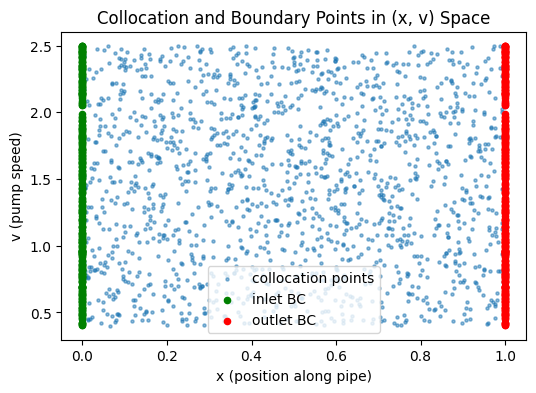

In [4]:
# plot the collocation points and the inlet and outlet boundary points in the (x, v) space
plt.figure(figsize=(6,4))
plt.scatter(x_f.cpu().numpy(), v_f.cpu().numpy(), s=5, label='collocation points', alpha=0.5)
plt.scatter(x0.cpu().numpy(), v_b.cpu().numpy(), s=20, label='inlet BC', color='green')
plt.scatter(xL.cpu().numpy(), v_b.cpu().numpy(), s=20, label='outlet BC', color='red')
plt.xlabel("x (position along pipe)"); plt.ylabel("v (pump speed)")
plt.title("Collocation and Boundary Points in (x, v) Space")
plt.legend()
plt.show()

iter     0 | loss 2.667e+01 | pde 5.15e-02 | in 1.33e+00 | out 1.18e-03
iter  1000 | loss 2.521e-02 | pde 2.41e-02 | in 7.82e-06 | out 4.80e-05
iter  2000 | loss 1.680e-02 | pde 1.64e-02 | in 9.76e-06 | out 1.11e-05
iter  3000 | loss 1.291e-02 | pde 1.27e-02 | in 4.55e-06 | out 8.18e-06
iter  4000 | loss 1.007e-02 | pde 9.94e-03 | in 3.41e-06 | out 3.00e-06


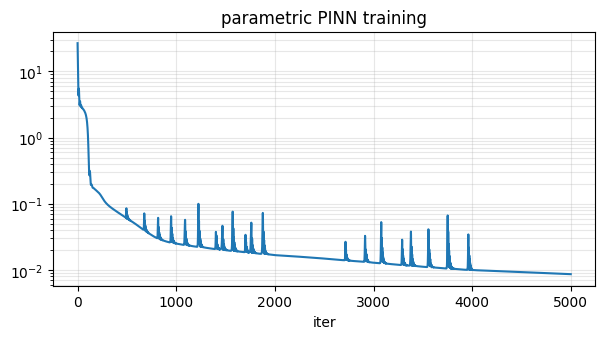

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

hist = []
for it in range(5000):                     # ~2-3 min on CPU
    optimizer.zero_grad()
    loss_pde = torch.mean(residual(x_f, v_f)**2)
    loss_in  = torch.mean((model(x0, v_b) - 1.0)**2) # inlet boundary condition: theta(0, v) = 1
    loss_out = torch.mean(outflow(xL, v_b)**2) # outlet boudnary condition: dtheta/dx(L, v) = 0
    loss = loss_pde + 20.0*(loss_in + loss_out)
    loss.backward(); optimizer.step(); scheduler.step()
    hist.append(loss.item())
    if it % 1000 == 0:
        print(f"iter {it:5d} | loss {loss.item():.3e} | pde {loss_pde.item():.2e} | in {loss_in.item():.2e} | out {loss_out.item():.2e}")
plt.figure(figsize=(7,3.3)); plt.semilogy(hist); plt.title("parametric PINN training"); plt.xlabel("iter"); plt.grid(True, which="both", alpha=0.3); plt.show()

## 4. Check the surrogate against the classical solver

Before trusting it for optimisation, verify the one trained network matches finite-difference solutions at
several pump speeds it was **not** explicitly told about.

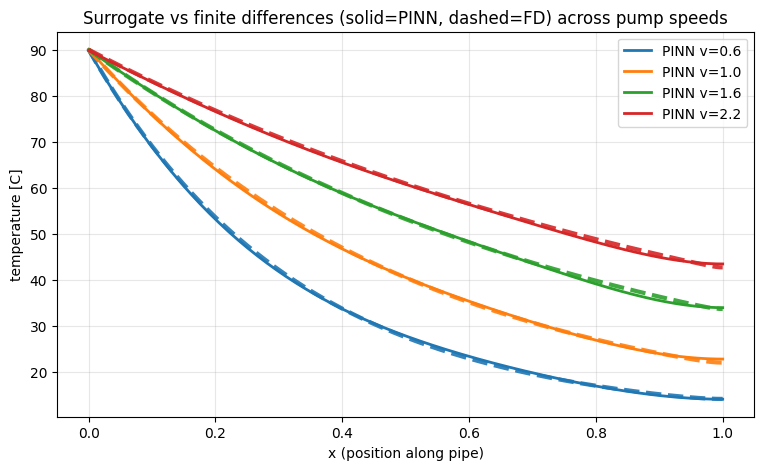

In [8]:
plt.figure(figsize=(9,5))
xg = torch.linspace(0, L, 200, device=device).reshape(-1,1)
for vv in [0.6, 1.0, 1.6, 2.2]:
    vt = torch.full_like(xg, vv)
    with torch.no_grad():
        th = model(xg, vt).cpu().numpy().flatten()
    p = plt.plot(xg.cpu().numpy().flatten(), to_celsius(th), lw=2, label=f"PINN v={vv}")
    xf, thf = steady_state_fd(vv)
    plt.plot(xf, to_celsius(thf), "--", color=p[0].get_color(), lw=3, alpha=0.9)
plt.xlabel("x (position along pipe)"); plt.ylabel("temperature [C]")
plt.title("Surrogate vs finite differences (solid=PINN, dashed=FD) across pump speeds")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. The cost function to minimise

We combine the two competing effects into one cost, evaluated **through the surrogate**:

$$J(v) = \underbrace{w_T\big(\theta_\text{out}(v)-\theta^\star\big)^2}_{\text{miss the delivery target}}
\;+\; \underbrace{w_P\Big(\tfrac{v}{v_\text{ref}}\Big)^3}_{\text{pumping energy }\propto v^3}$$

where $\theta_\text{out}(v)=\theta(L; v)$ comes straight from the PINN. 
- Too slow → cold delivery (first term
blows up)
- Too fast → wasted pumping energy (second term blows up). Somewhere in between is the sweet spot.

In [10]:
theta_target = 0.35            # required normalized delivery temperature (~38 C)
w_T, w_P, v_ref = 1.0, 0.02, v_hi
xL_t = torch.tensor([[L]], dtype=torch.float32, device=device)

def cost(v_tensor):
    theta_out = model(xL_t, v_tensor)                       # differentiable in v
    miss = w_T*(theta_out - theta_target)**2
    pump = w_P*(v_tensor/v_ref)**3
    return (miss + pump).squeeze(), theta_out.squeeze()

# brute-force scan just to SEE the landscape (not used for optimisation)
# we use a grid of 200 points in the range [v_lo, v_hi] to evaluate the cost function and find the minimum. 
# This is not an optimization step, but rather a way to visualize the cost landscape and get an idea of where the optimum might be.   
v_scan = np.linspace(v_lo, v_hi, 200)
J_scan = []
for vv in v_scan:
    with torch.no_grad():
        J,_ = cost(torch.tensor([[vv]], dtype=torch.float32, device=device))
    J_scan.append(J.item())
J_scan = np.array(J_scan)
v_star_scan = v_scan[np.argmin(J_scan)]
print(f"scan suggests optimum near v = {v_star_scan:.3f}")

scan suggests optimum near v = 1.709


## So why bother with gradients? Dimensionality.
Grid search cost scales as N^d (N points per axis, d knobs). Gradient cost scales ~independently of d. That's the whole ballgame:

| Control Knobs ($d$) | Grid Search (@ 200 pts/axis) | Gradient Descent |
| :--- | :--- | :--- |
| **1** (pump speed) | 200 evals — *trivial, use the scan* | ~400 steps |
| **2** (+ inlet temp) | 40,000 evals | ~400 steps |
| **5** | 3.2 × 10¹¹ evals | ~400 steps |
| **24** (hourly pump schedule over a day) | 200²⁴ ≈ 10⁵⁵ evals — *heat death of the universe* | ~400 steps |

One backward pass gives you ∂J/∂(every knob) simultaneously, at roughly the cost of one forward pass — regardless of how many knobs there are.

Compare the alternatives for d knobs:

- Grid search: N^d evaluations
- Finite-difference gradient: d + 1 evaluations (and you must pick a step size, and it's numerically noisy)
- Reverse-mode AD (what the PINN gives you): ~1 evaluation, exact

So the gradient isn't competing with the scan on this problem. It's the only thing that still works when the problem gets real.

## 6. Optimise the control by gradient descent **through** the PINN

Here is the payoff. We make the pump speed `v` a **trainable tensor**, freeze the model, and let Adam minimise
$J(v)$. Every step uses autograd to get the *exact* $\frac{dJ}{dv}$ by back-propagating through the surrogate —
no simulator in the loop. We start deliberately too slow ($v=0.6$) and watch it climb to the optimum.

In [11]:
for p in model.parameters():          # freeze the twin
    # we don't want to update the surrogate model during the control optimization, 
    # so we set requires_grad to False for all parameters of the model.
    p.requires_grad_(False)

# v_ctrl is the control variable (pump speed) that we want to optimize. 
# We initialize it to 0.6 and set requires_grad=True so that we can compute gradients with respect to it.
v_ctrl = torch.tensor([[0.6]], dtype=torch.float32, device=device, requires_grad=True)
opt_ctrl = torch.optim.Adam([v_ctrl], lr=0.03) # now the optimizer will only update v_ctrl, not the model parameters.

v_path, J_path = [], []
for step in range(400):
    opt_ctrl.zero_grad()
    J, _ = cost(v_ctrl) # normally here we have loss
    J.backward() # normally here we do loss.backward()
    opt_ctrl.step()
    with torch.no_grad():
        v_ctrl.clamp_(v_lo, v_hi)      # keep within the pump's operating range
    v_path.append(v_ctrl.item()); J_path.append(J.item())

v_opt = v_ctrl.item()
with torch.no_grad():
    _, th_out_opt = cost(torch.tensor([[v_opt]], dtype=torch.float32, device=device))
print(f"optimised pump speed v* = {v_opt:.3f}")
print(f"delivery temperature at v*: theta={th_out_opt.item():.3f}  ->  {to_celsius(th_out_opt.item()):.1f} C  (target {to_celsius(theta_target):.1f} C)")

optimised pump speed v* = 1.708
delivery temperature at v*: theta=0.324  ->  35.9 C  (target 38.0 C)


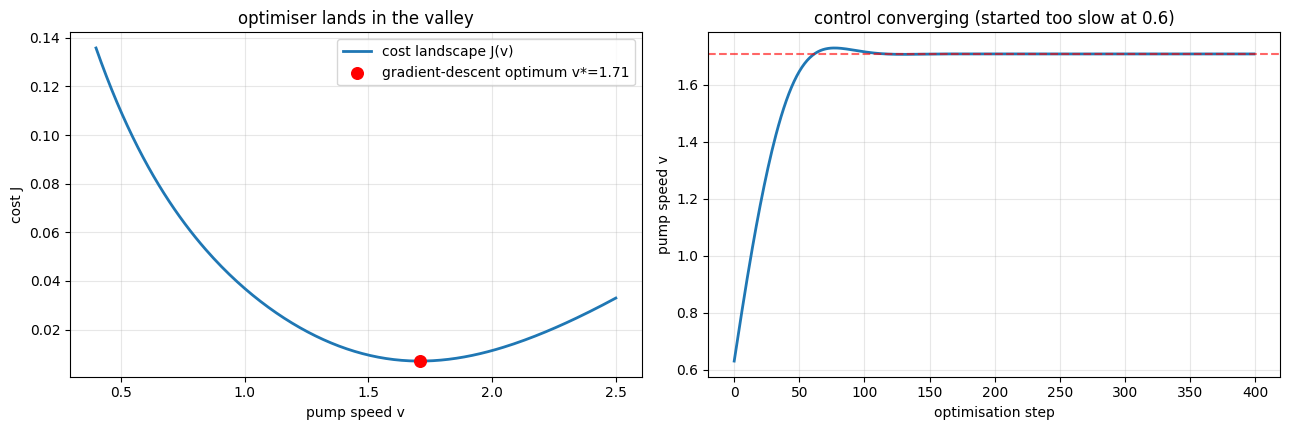

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(v_scan, J_scan, lw=2, label="cost landscape J(v)")
ax[0].scatter([v_opt], [J_path[-1]], color="red", zorder=5, s=70, label=f"gradient-descent optimum v*={v_opt:.2f}")
ax[0].set_xlabel("pump speed v"); ax[0].set_ylabel("cost J"); ax[0].set_title("optimiser lands in the valley")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(v_path, lw=2)
ax[1].axhline(v_opt, color="red", ls="--", alpha=0.6)
ax[1].set_xlabel("optimisation step"); ax[1].set_ylabel("pump speed v")
ax[1].set_title("control converging (started too slow at 0.6)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. What just happened, and why it matters commercially

- We trained **one** PINN that captures the pipe for **every** pump speed in range.
- We wrote a business **cost** (delivery target vs pumping energy) as a function of the network output.
- We found the optimal setpoint by **back-propagating through the frozen twin** — the gradient $\frac{dJ}{dv}$
  came for free from autograd, so optimisation was a few hundred cheap forward/backward passes, **no simulator
  re-runs**.

Scale this up and it becomes real product capability:

- **Design optimisation**: many geometric/material knobs at once — gradient-based search stays cheap where
  finite-difference-over-a-simulator explodes.
- **Model-predictive control (MPC)**: the differentiable twin sits inside a controller that re-optimises
  setpoints every few minutes as demand and weather change.
- **Real-time "what-if"**: operators slide the pump speed and instantly see delivery temperature and cost.

**The pattern:** *train a differentiable physics twin once, then optimise/control against it forever.* Combine
this with notebook 04/05's parameter discovery and you have a twin that both **stays calibrated to sensors** and
**tells you the best action** — the heart of an industrial PINN application.

## 8. Experiments

1. **Change the target.** Set `theta_target = 0.5` (hotter delivery). The optimum pump speed rises — re-run the
   control cell and watch `v*` move.
2. **Cheaper/greener pumping.** Lower `w_P = 0.005`. The optimiser tolerates faster flow. Higher `w_P` pushes it
   slower. This is literally the energy-price knob.
3. **Two controls.** Advanced: add inlet temperature as a second input to the PINN and optimise `(v, inlet)`
   jointly — the differentiable-surrogate advantage grows with the number of knobs.

## 9. Recap

- A trained PINN is a **differentiable surrogate**: you can optimise *inputs/controls* by back-propagating
  through it, not just solve for outputs.
- A **parametric PINN** (control as an extra input) captures a whole family of scenarios in one model.
- We optimised a district-heating **pump speed** for minimum energy at a delivery target — with no simulator in
  the optimisation loop.
- This unlocks **design optimisation and control**, the second big ✅ in the "when to use a PINN" table.